In [1]:
# Tutorial
# https://nbviewer.org/github/OpenPIV/openpiv-python-examples/blob/main/notebooks/PIV_3D_example.ipynb
# GUI: https://pypi.org/project/openpivgui/

In [2]:
from openpiv.pyprocess3D import *
from openpiv.PIV_3D_plotting import *
from openpiv.validation import sig2noise_val
from openpiv.filters import replace_outliers
from openpiv.lib import replace_nans
import glob as glob
import numpy as np
import os
from natsort import natsorted
import matplotlib.animation as animation

In [3]:
before_directory = 'data/data-PIV3D-1/BEFORE.tif.frames/'
after_directory  = 'data/data-PIV3D-1/AFTER .tif.frames/'

In [4]:

# Convert from RGB to grayscale
def RGB_TO_GRAY(image):
    return np.dot(image[..., :3], [0.2989, 0.5870, 0.1140])


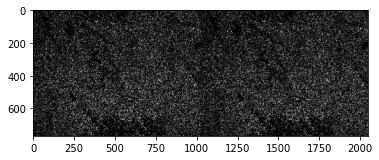

In [5]:
# Load image stacks

before_images = natsorted(glob.glob(os.path.join(before_directory, "BEFORE_C001Z*.tif")))
after_images  = natsorted(glob.glob(os.path.join(after_directory, "AFTER _C001Z*.tif")))

before_sample = RGB_TO_GRAY(plt.imread(before_images[0]))
after_sample  = RGB_TO_GRAY(plt.imread(after_images[0]))

image_shape = before_sample.shape

# Display a before and after slice
plt.imshow(np.hstack([before_sample, after_sample]), cmap = plt.get_cmap('gray'))

In [ ]:

# Load images into 3D stack array
before_array = np.zeros((image_shape[0], image_shape[1], len(before_images)))
after_array  = np.zeros((image_shape[0], image_shape[1], len(after_images)))

for i, image in enumerate(before_images):
	before_array[:, :, i] = RGB_TO_GRAY(plt.imread(image))

for i, image in enumerate(after_images):
	after_array[:, :, i] = RGB_TO_GRAY(plt.imread(image))

before_array.shape

In [ ]:

# stack properties
# factors for voxel size
# du = 1.406
# dv = 1.406
# dw = 0.3

du = 0.3
dv = 0.3
dw = 1.406

# total image dimension for x y z
# image_dim = (123.02, 123.02, 122.86)
image_dim = (image_shape[0] * du, image_shape[1] * dv, len(after_images) * dw)
print(image_dim)

# keep these values for our nk cells stacks
win_um = 12  # window size in µm
fac_overlap = 0.3  # overlap in percent of the window size
signoise_filter = 1.3

In [8]:
# window size for stacks in pixel
window_size = (int(win_um / du), int(win_um / dv), int(win_um / dw))
overlap = (int(fac_overlap * win_um / du), int(fac_overlap * win_um / dv), int(fac_overlap * win_um / dw))
search_area = (int(win_um / du), int(win_um / dv), int(win_um / dw))

In [9]:
print(image_dim, window_size, overlap, search_area)

(230.39999999999998, 307.2, 49.209999999999994) (40, 40, 8) (12, 12, 2) (40, 40, 8)


In [10]:
# Calculate 3D Particle Image Velocimetry
# https://openpiv.readthedocs.io/en/latest/src/openpiv.html
u, v, w, sig2noise = extended_search_area_piv3D(
	before_array, after_array, 
	window_size = window_size, 
	overlap = overlap,
	search_area_size = search_area, 
	dt = (1 / du, 1 / dv, 1 / dw),
	subpixel_method = 'gaussian',
	sig2noise_method = 'peak2peak',
	width = 2
)

100%|██████████| 27/27 [04:15<00:00,  9.48s/it]


In [11]:
# Correcting stage drift between the field of views
u -= np.nanmean(u)
v -= np.nanmean(v)
w -= np.nanmean(w)

In [12]:
u.shape, v.shape, w.shape

((27, 36, 5), (27, 36, 5), (27, 36, 5))

In [14]:
# Filtering
mask = sig2noise_val(sig2noise, threshold=signoise_filter)
uf, vf, wf = replace_outliers(u, v, mask, w=w, max_iter=1, tol=100, kernel_size=2, method='disk')

TypeError: sig2noise_val() missing 2 required positional arguments: 'v' and 's2n'

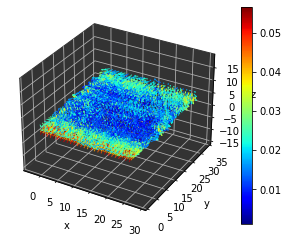

In [15]:
# unfiltered 3d deformation field
fig11 = quiver_3D(-u, v, w, quiv_args={"length": 0.1, "alpha": 0.8, "linewidth": 1})#, filter_def=0.1)

In [16]:
# filtered 3d deformation field
fig12 = quiver_3D(-uf, vf, wf, quiv_args={"length": 2, "alpha": 0.8, "linewidth": 1}) #, filter_def=0.1)

NameError: name 'uf' is not defined